In [1]:
import Voronoi as Voronoi
import MonteCarlo as MonteCarlo
import Graphene as Graphene
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

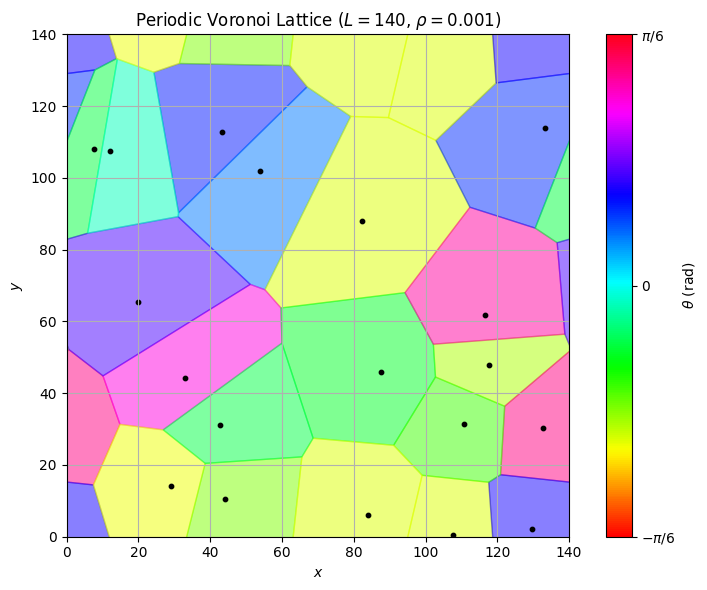

Monte Carlo Sweeps: 100%|██████████| 100000/100000 [00:00<00:00, 179811.47it/s]


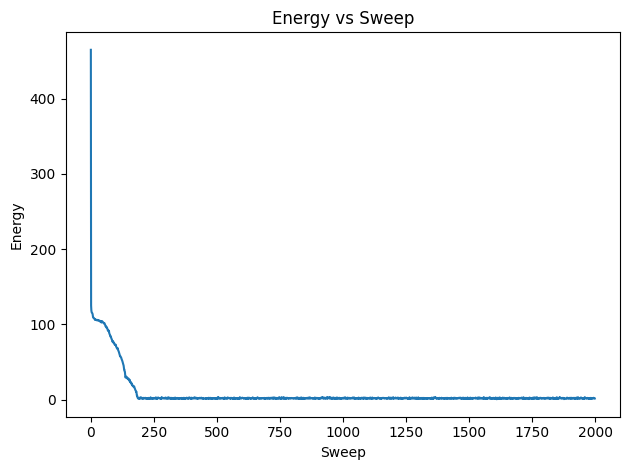

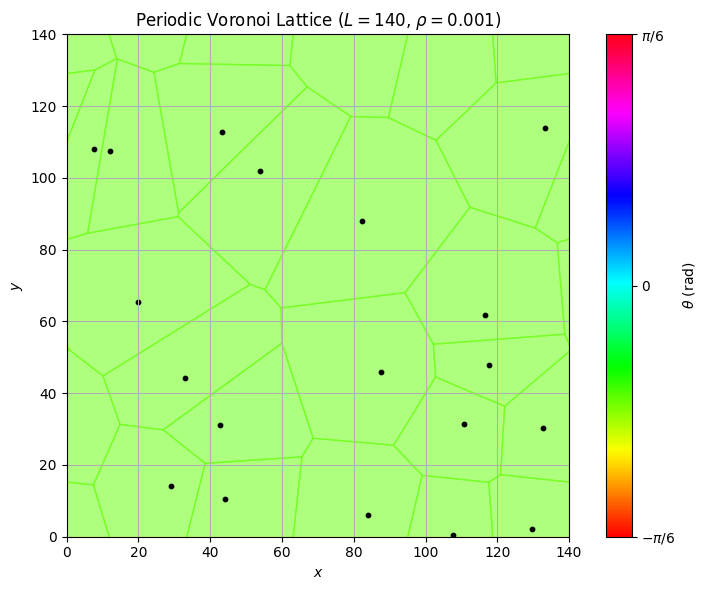

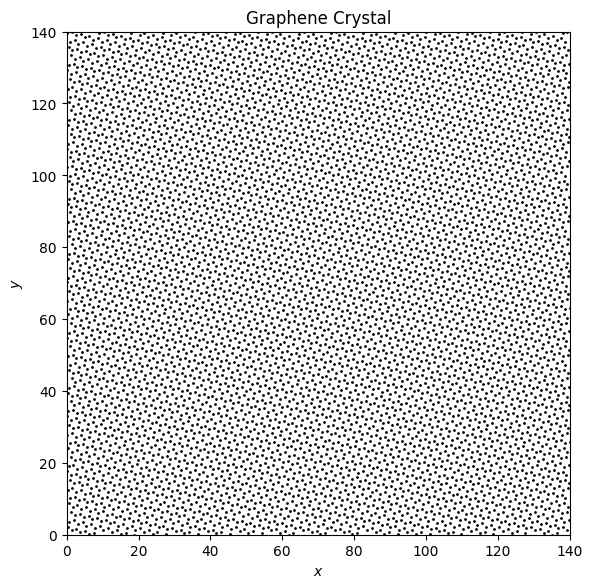

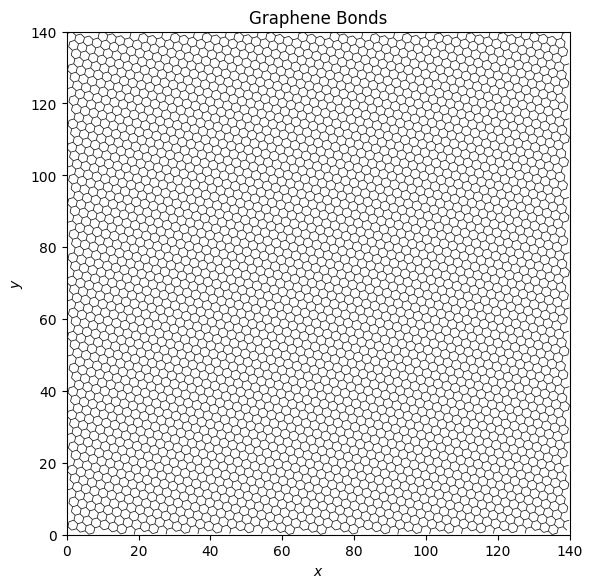

C:\Users\Alexi\AppData\Local\Temp\ipykernel_7288\1331891535.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


ValueError: x and y must have same first dimension, but have shapes (140,) and (141,)

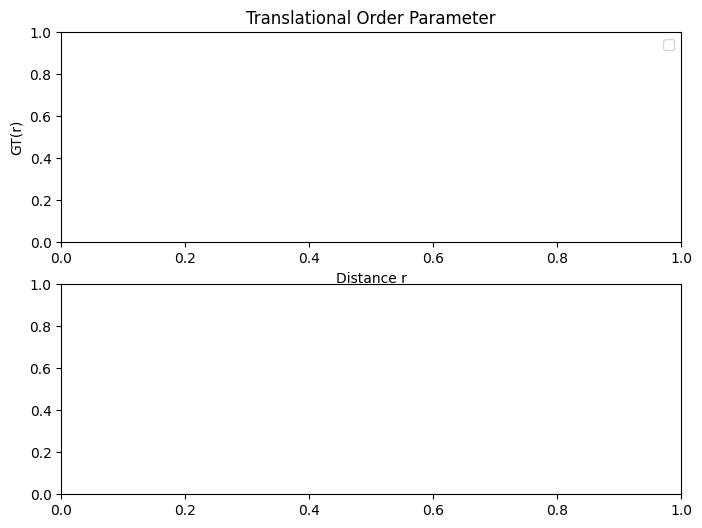

In [ ]:
L = 140
rho = 0.001
lat = Voronoi.PeriodicVoronoi(L, rho)
lat.plot()
plt.show()

T = 0.1
beta = 1 / T
epsilon = 0.0
gamma = 1.0
theta, energy = MonteCarlo.monte_carlo(lat.theta.copy(), lat.adj_i, lat.adj_j, lat.adj_length, beta, epsilon, rho, gamma, n_sweeps=100000)

plt.plot(energy)
plt.xlabel('Sweep')
plt.ylabel('Energy')
plt.title('Energy vs Sweep')
plt.tight_layout()
plt.show()

lat.theta = theta
lat.plot()
plt.show()

graphene = Graphene.GrapheneCrystal(lat, a=1.42)
graphene.plot_atoms()
plt.show()

graphene.plot_bonds()
plt.show()

psi6, psi_T, (r_centers1, GT), (r_centers2, G6) = graphene.compute_observables()
plt.plot(r_centers1, GT, label='Translational Order')
plt.xlabel('Distance r')
plt.ylabel('GT(r)')
plt.title('Translational Order Parameter')
plt.legend()
plt.show()
plt.plot(r_centers2, G6, label='Bond-Orientational Order')
plt.xlabel('Distance r')
plt.ylabel('G6(r)')
plt.title('Bond-Orientational Order Parameter')
plt.legend()
plt.show()
